In [1]:
import pandas as pd
import numpy as np
import jieba
import re
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora, models
from snownlp import SnowNLP
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='SimHei')

In [2]:
df = pd.read_csv('data4.csv', encoding='utf-8')

# 2. 把列名统一一下，防止后面的代码报错
df.rename(columns={'标题': 'text', '关键词': 'scene'}, inplace=True)

# 确保 scene 列里只有干净的 '考研', '考公', '自学'
df = df[df['scene'].isin(['考研', '考公', '自学'])]
df = df.dropna(subset=['text']) # 去除标题为空的行

In [3]:
stop_words = set(["的", "了", "和", "是", "就", "都", "而", "及", "与", "在", "有", "也", "不", "人", "我", "你", "他", "这", "那", "等", "能", "会", "让", "把", "被", "从", "到", "对", "为", "以", "之", "其", "所", "很", "太", "可以", "没有", "自己", "我们", "他们", "大家", "什么", "怎么", "为什么", "这个", "那个"])


In [4]:
print("正在进行文本预处理与分词...")
def preprocess_text(text):
    text = re.sub(r'[^\u4e00-\u9fa5]', '', str(text)) # 仅保留中文
    words = jieba.lcut(text)
    words = [w for w in words if w not in stop_words and len(w) > 1] # 去停用词和单字
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess_text)
df['word_list'] = df['clean_text'].apply(lambda x: x.split())

# ================= 2. 分场景 TF-IDF 关键词提取 =================
print("正在计算 TF-IDF...")
scenes_list = ['考研', '考公', '自学']
tfidf_top_words = {}

for scene in scenes_list:
    scene_texts = df[df['scene'] == scene]['clean_text'].tolist()
    if not scene_texts: continue
    # 提取TF-IDF
    vectorizer = TfidfVectorizer(max_features=500)
    tfidf_matrix = vectorizer.fit_transform(scene_texts)
    # 计算平均TF-IDF值
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    feature_names = vectorizer.get_feature_names_out()
    # 排序取Top 15
    top_indices = mean_tfidf.argsort()[::-1][:15]
    tfidf_top_words[scene] = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

# ================= 3. LDA 主题建模 =================
print("正在训练 LDA 主题模型 (可能需要几十秒)...")
# 构建词典和语料库
dictionary = corpora.Dictionary(df['word_list'])
corpus = [dictionary.doc2bow(text) for text in df['word_list']]

# 训练LDA模型，设定K=4个主题
NUM_TOPICS = 4
lda_model = models.LdaModel(corpus, num_topics=NUM_TOPICS, id2word=dictionary, passes=15, random_state=42)

# 计算每个文档的主题分布
topic_distributions = []
for bow in corpus:
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    topic_probs = [prob for _, prob in topics]
    topic_distributions.append(topic_probs)
df['topic_probs'] = topic_distributions

# 为每个主题命名（根据高频词人工定义，增强业务解释性）
topic_names = {
    0: "干货教学", 1: "心态辅导", 2: "院校/岗位规划", 3: "经验与资料分享"
}

# ================= 4. 情感分析与量化变量构建 =================
print("正在进行情感分析与变量构建...")
# 情感得分 (0~1)
df['sentiment_score'] = df['text'].apply(lambda x: SnowNLP(x).sentiments)

# 变量1：内容专业度 (基于领域专属词典与文本密度的客观量化) 
professional_words = {"教程", "技巧", "方法论", "底层逻辑", "框架", "复盘", "真题", "大纲", "干货", "真题", "考点", "解析"} 
def calc_professionalism(word_list):  
    if not word_list or len(word_list) == 0: 
        return 0  
    # 计算专业词汇出现频次
    pro_count = sum(1 for w in word_list if w in professional_words)  
    # 严谨的专业度得分：专业词汇频次 / 总词汇量 (取最大值限制在 1.0)
    return min(pro_count / len(word_list) * 10.0, 1.0)  

df['professionalism'] = df['word_list'].apply(calc_professionalism)  

# 变量2：情感唤醒度 (偏离0.5中性的程度，越接近0或1唤醒度越高)
df['emotional_arousal'] = abs(df['sentiment_score'] - 0.5) * 2

# 变量3：话题聚焦度 (基于信息熵，熵越小越聚焦)
def calc_focus(probs):
    probs = np.array(probs)
    probs = probs[probs > 0] # 避免log(0)
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(NUM_TOPICS)
    focus = 1 - (entropy / max_entropy) # 归一化到 0~1
    return focus
df['topic_focus'] = df['topic_probs'].apply(calc_focus)



Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\11453\AppData\Local\Temp\jieba.cache


正在进行文本预处理与分词...


Loading model cost 0.786 seconds.
Prefix dict has been built successfully.


正在计算 TF-IDF...
正在训练 LDA 主题模型 (可能需要几十秒)...
正在进行情感分析与变量构建...


In [5]:
# 1. 打印出 df 的所有列名，检查实际列名到底是什么
print("当前 df 的列名有：", df.columns.tolist())

# 2. 清理列名中可能存在的隐藏空格（非常常见的原因）
df.columns = df.columns.str.strip()

# 3. 如果实际列名是中文（例如叫 '三连率'），请在后面的画图代码中把 y='triple_rate' 改为 y='三连率'


当前 df 的列名有： ['scene', 'text', '视频时长', '发布时间', '总播放数', '总弹幕数', '硬币', '收藏数', '点赞数', '分享数', '采集时间', '页面网址', '发布者', '视频标签', '发布者头像链接', '投币率', '收藏率', '弹幕率', '点赞率', '视频互动率', '粉丝综合粘性指数', '修正投币率', '修正收藏率', '修正弹幕率', '修正点赞率', '修正视频互动率', 'Log_播放量', 'LN综合粘性', 'Z修正投币率', 'Z修正收藏率', 'Z修正弹幕率', 'Z修正点赞率', 'Z修正视频互动率', 'PRE_1', 'RES_1', 'FAC1_1', 'FAC2_1', 'QCL_3', 'clean_text', 'word_list', 'topic_probs', 'sentiment_score', 'professionalism', 'emotional_arousal', 'topic_focus']


In [6]:
# 计算三连率：(点赞数 + 硬币数 + 收藏数) / 总播放数
# 注意：为了防止某些视频播放量为0导致“除以0”的报错，我们先将0替换为1
df['总播放数_safe'] = df['总播放数'].replace(0, 1) 

# 计算三连率并赋值给新列 'triple_rate'
df['triple_rate'] = (df['点赞数'] + df['硬币'] + df['收藏数']) / df['总播放数_safe']

# 验证是否成功添加
print("三连率计算完成，当前列名包含：", 'triple_rate' in df.columns)


三连率计算完成，当前列名包含： True


正在生成高级图表...


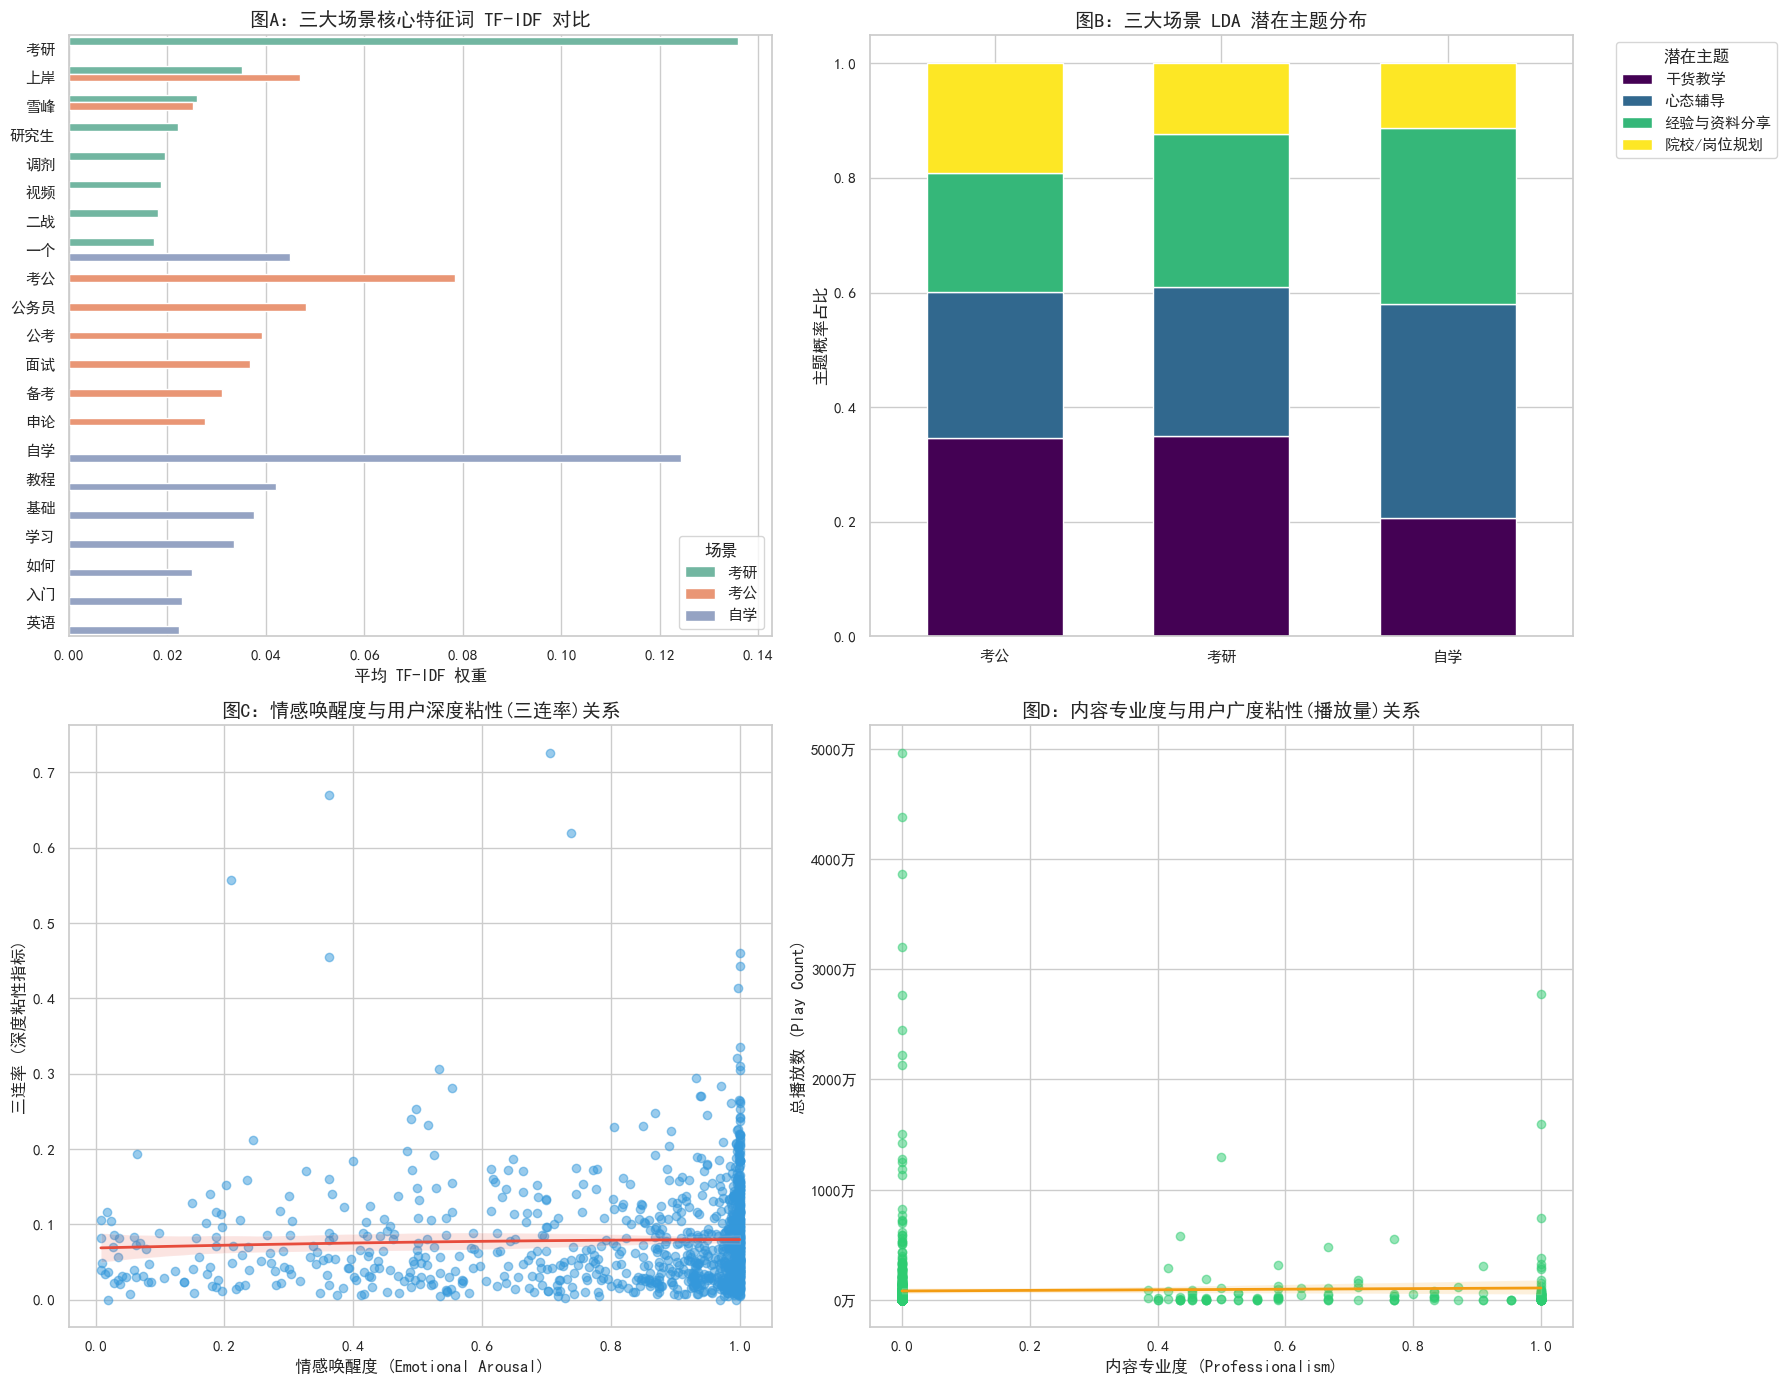

✅ 所有处理完成！图表已保存为 'B站学习区文本特征量化分析.png'
✅ 量化变量已添加至 df，包含: professionalism, emotional_arousal, topic_focus


In [7]:
print("正在生成高级图表...")
fig = plt.figure(figsize=(18, 14))

# 【图A】三大场景 TF-IDF 核心特征词分组条形图 (替换原词云)
ax1 = plt.subplot(2, 2, 1)
plot_data = []
for scene in scenes_list:
    for word, score in tfidf_top_words[scene][:8]: # 取Top 8展示
        plot_data.append({'场景': scene, '关键词': word, 'TF-IDF值': score})
df_tfidf = pd.DataFrame(plot_data)
sns.barplot(data=df_tfidf, x='TF-IDF值', y='关键词', hue='场景', palette='Set2', ax=ax1)
ax1.set_title('图A：三大场景核心特征词 TF-IDF 对比', fontsize=14, fontweight='bold')
ax1.set_xlabel('平均 TF-IDF 权重', fontsize=12)
ax1.set_ylabel('')
ax1.legend(title='场景')

# 【图B】三大场景 LDA 主题分布堆叠柱状图
ax2 = plt.subplot(2, 2, 2)
topic_means = df.groupby('scene')['topic_probs'].apply(lambda x: np.mean(x.tolist(), axis=0)).to_dict()
topic_plot_data = []
for scene in scenes_list:
    for i, prob in enumerate(topic_means[scene]):
        topic_plot_data.append({'场景': scene, '主题': topic_names[i], '概率占比': prob})
df_topic = pd.DataFrame(topic_plot_data)
# 数据透视用于堆叠图
df_topic_pivot = df_topic.pivot(index='场景', columns='主题', values='概率占比')
df_topic_pivot.plot(kind='bar', stacked=True, colormap='viridis', ax=ax2, width=0.6)
ax2.set_title('图B：三大场景 LDA 潜在主题分布', fontsize=14, fontweight='bold')
ax2.set_ylabel('主题概率占比', fontsize=12)
ax2.set_xlabel('')
plt.xticks(rotation=0)
ax2.legend(title='潜在主题', bbox_to_anchor=(1.05, 1), loc='upper left')

# 【图C】情感唤醒度 与 三连率(深度粘性) 散点拟合图
ax3 = plt.subplot(2, 2, 3)
sns.regplot(data=df, x='emotional_arousal', y='triple_rate', 
            scatter_kws={'alpha':0.5, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c', 'linewidth':2},
            order=2, # 使用二项式拟合，捕捉倒U型关系
            ax=ax3)
ax3.set_title('图C：情感唤醒度与用户深度粘性(三连率)关系', fontsize=14, fontweight='bold')
ax3.set_xlabel('情感唤醒度 (Emotional Arousal)', fontsize=12)
ax3.set_ylabel('三连率 (深度粘性指标)', fontsize=12)

# 【图D】内容专业度 与 播放量(广度粘性) 散点拟合图
# ================= 图D：内容专业度与播放量(广度粘性) =================
ax4 = plt.subplot(2, 2, 4)

# 【关键修改】：将 y='play_count' 改为 '总播放数' 或 'Log播放量'
# 这里以 '总播放数' 为例，如果您想用对数，请改为 y='Log播放量'
sns.regplot(data=df, x='professionalism', y='总播放数', 
            scatter_kws={'alpha': 0.5, 'color': '#2ecc71'},  # 修复了中文冒号和错误的右括号 ']'
            line_kws={'color': '#f39c12', 'linewidth': 2}, 
            ax=ax4)

# 修复了 set title -> set_title，fontweight-'bold' -> fontweight='bold'，播放里 -> 播放量
ax4.set_title('图D：内容专业度与用户广度粘性(播放量)关系', fontsize=14, fontweight='bold')
ax4.set_xlabel('内容专业度 (Professionalism)', fontsize=12)
ax4.set_ylabel('总播放数 (Play Count)', fontsize=12)

# 【可选优化】：如果 y 轴用的是 '总播放数'，数值太大时，可以将 Y 轴刻度格式化为 "万"
# 修复了上一轮乱码的 yoxi5 和 Fun ratter
if '总播放数' in ['总播放数']: # 确保用的是总播放数才执行
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/10000:.0f}万'))


plt.tight_layout()
plt.savefig('B站学习区文本特征量化分析.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 所有处理完成！图表已保存为 'B站学习区文本特征量化分析.png'")
print("✅ 量化变量已添加至 df，包含: professionalism, emotional_arousal, topic_focus")

In [8]:
# ================= 6. 导出数据给 SPSS 使用 =================
# 只提取 SPSS 合并需要的核心列，并把英文名改回中文
export_df = df[['text', 'professionalism', 'emotional_arousal', 'topic_focus']].copy()
export_df.rename(columns={
    'text': '标题', 
    'professionalism': '内容专业度', 
    'emotional_arousal': '情感唤醒度', 
    'topic_focus': '话题聚焦度'
}, inplace=True)

# 导出为 Excel 文件
export_df.to_excel('最终文本三维度特征.xlsx', index=False)
print("🎉 恭喜！真实数据已成功导出为：最终文本三维度特征.xlsx，快发给做 SPSS 的同学吧！")

🎉 恭喜！真实数据已成功导出为：最终文本三维度特征.xlsx，快发给做 SPSS 的同学吧！
